In [1]:
import cv2, numpy as np, matplotlib.pyplot as plt

In [2]:
img = cv2.imread('data/cv-sample.png')
if img is None:
    raise Exception("Image not found")

print("shape:", img.shape) #height,width,channels
print("dtype:", img.dtype) #uint8
print("pixel at (x=10, y=20):", img[20,10]) #[B,G,R]

shape: (1280, 1920, 3)
dtype: uint8
pixel at (x=10, y=20): [19 19  6]


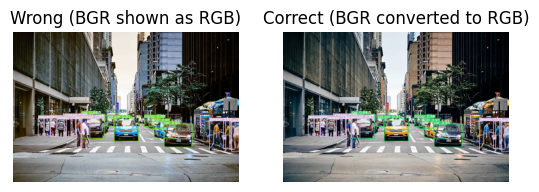

In [3]:
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Wrong (BGR shown as RGB)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Correct (BGR converted to RGB)")
plt.axis("off")

plt.show()

In [4]:
print("pixel at center:", img[img.shape[0]//2, img.shape[1]//2]) #[B,G,R]

pixel at center: [253 253 253]


In [ ]:
h, w = img.shape[:2]

half = cv2.resize(img, None, fx=0.5, fy=0.5)    # by scale factor, keeping aspect ratio
fixed = cv2.resize(img, (640, 480))             # exact size: (WIDTH, HEIGHT)

print("original:", img.shape)
print("half:", half.shape)
print("fixed:", fixed.shape)

original: (1280, 1920, 3)
half: (640, 960, 3)
fixed: (480, 640, 3)


#### cropping

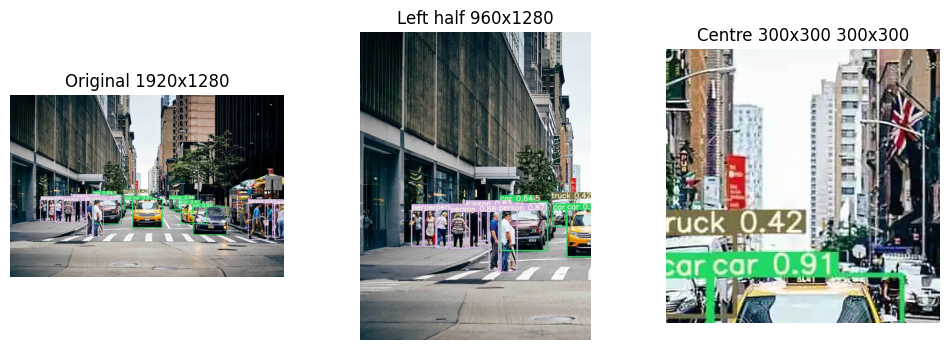

In [7]:
left_half = img[:, :w // 2] # all rows, left half columns
# 300x300 box in the middle
center = img[h//2 - 150 : h//2 + 150, w//2 - 150 : w//2 + 150].copy()

plt.figure(figsize=(12,4))
for i, (im, t) in enumerate([(img, "Original"), (left_half, "Left half"), (center, "Centre 300x300")]):
    plt.subplot(1, 3, i+1)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(f"{t} {im.shape[1]}x{im.shape[0]}")
    plt.axis("off")
plt.show() 

In [8]:
def show(images, titles):
    plt.figure(figsize=(5 * len(images), 4))
    for i, (im, t) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if im.ndim == 3:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(im, cmap="gray")
        plt.title(t); plt.axis("off")
    plt.show()

#### blurring

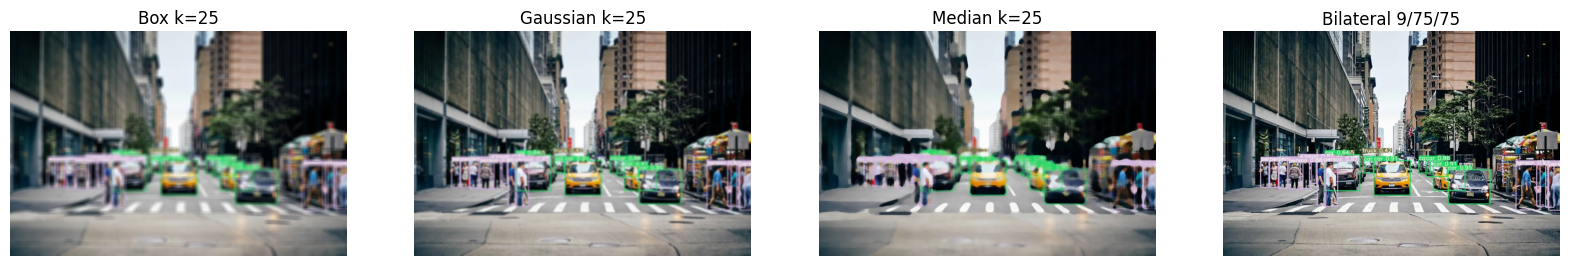

In [10]:
k = 25
box = cv2.blur(img, (k,k))
gaussian = cv2.GaussianBlur(img, (k,k), 0)      # 0 = let OpenCV pick sigma from k
median = cv2.medianBlur(img, k)                 # k must be odd
bilateral = cv2.bilateralFilter(img, 9, 75, 75) # d=9, sigmaColor=75, sigmaSpace=75

show([box, gaussian, median, bilateral], [f"Box k={k}", f"Gaussian k={k}", f"Median k={k}", "Bilateral 9/75/75"])

##### lab 1 Task 5, heavy blur + 300×300 centre ROI

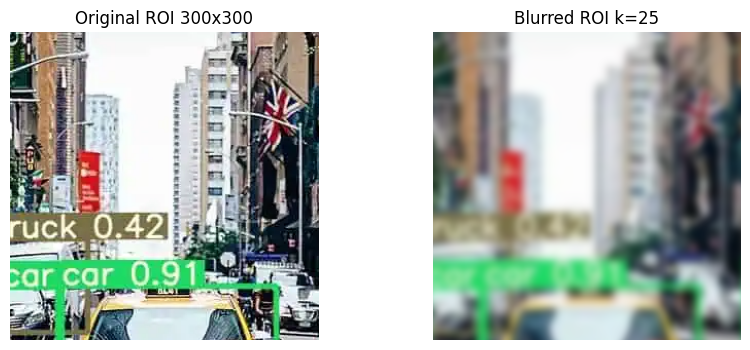

True

In [12]:
k, r = 25, 300
blurred = cv2.GaussianBlur(img, (k,k), 0)
x1, y1 = w // 2 - r // 2, h // 2 - r // 2       #top left of the center box

roi_original = img[y1:y1 + r, x1:x1 + r]
roi_blurred = blurred[y1:y1 + r, x1:x1 + r]
show([roi_original, roi_blurred], [f"Original ROI {r}x{r}", f"Blurred ROI k={k}"])
cv2.imwrite("output_roi_blur.png", roi_blurred)

"blur only the centre, keep the rest sharp"

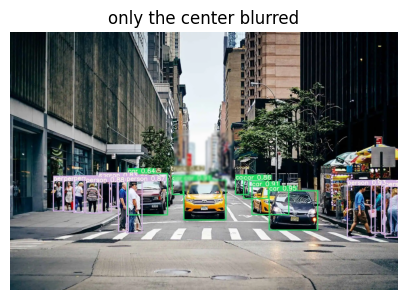

In [13]:
out = img.copy()
out[y1:y1 + r, x1:x1 + r] = cv2.GaussianBlur(out[y1:y1 + r, x1:x1 + r], (k,k), 0)
show([out], [f"only the center blurred"])

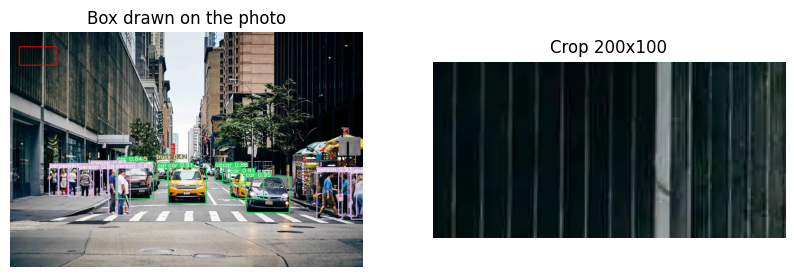

In [14]:
x, y, bw, bh = 50, 80, 200, 100             #corner(x,y), box width, box height
marked = img.copy()
cv2.rectangle(marked, (x,y), (x+bw, y+bh), (0,0,255), 4)    # drawing uses (x, y)
crop = img[y:y + bh, x:x + bw]                   #slicing uses (y, x)
show([marked, crop], ["Box drawn on the photo", f"Crop {crop.shape[1]}x{crop.shape[0]}"])

Every OpenCV drawing function follows the same pattern of image, position, colour, thickness

In [ ]:
cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)    # start point, end point
cv2.circle(img, (cx, cy), radius, (255, 0, 0), -1)   # centre point, radius

#### Text, circles and the transparent caption bar

In [ ]:
cv2.putText(img, "hello ibrahim", (50,100), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 3)

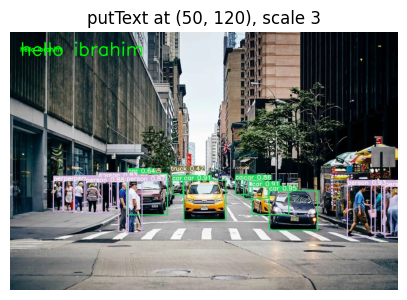

In [17]:
texted = img.copy()
cv2.putText(texted, "hello ibrahim", (50,120), cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 0), 6)
show([texted], ["putText at (50, 120), scale 3"])

concentric circles on an 800×800 canvas

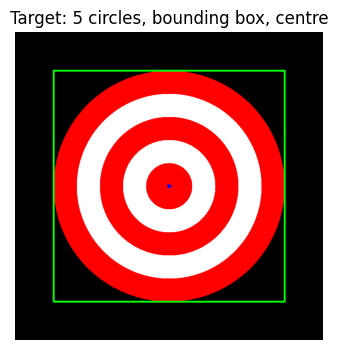

True

In [18]:
canvas = np.zeros((800,800,3), np.uint8)
cx, cy = 400, 400                       # centre of an 800x800 canvas
radii = [300, 240, 180, 120, 60]        # biggest first
colors = [(0, 0, 255), (255, 255, 255)]     # red, white (BGR)

for i, r in enumerate(radii):
    cv2.circle(canvas, (cx,cy), r, colors[i%2], -1)  # i % 2 alternates 0,1,0,1,0
    
R = radii[0]

cv2.rectangle(canvas, (cx - R, cy - R), (cx + R, cy + R), (0,255,0), 3)     #box around outer circle

cv2.circle(canvas, (cx,cy), 5, (255,0,0), -1)  # centre point

show([canvas], ["Target: 5 circles, bounding box, centre"])
cv2.imwrite("task4_target.png", canvas)

##### lab 1 task 6, a semi-transparent bar on the bottom 20%

Theory: cv2.addWeighted mixes two images pixel by pixel:

result = α · image1 + β · image2 + γ

The trick for transparency:

1. Make a copy of the photo and draw a solid bar on the copy.
2. Blend the copy with the original. The bar comes out see-through; everything else is unchanged, because it's the same in both images.

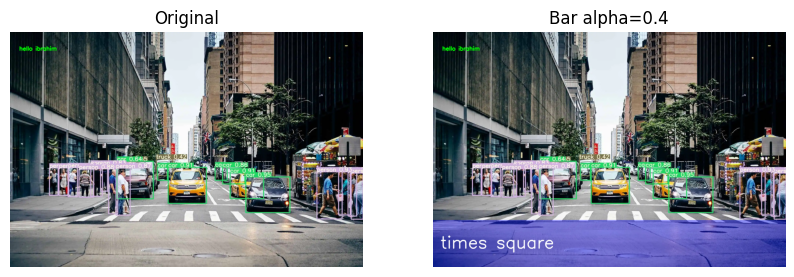

True

In [19]:
alpha = 0.4
overlay = img.copy()
cv2.rectangle(overlay, (0, int(h * 0.8)), (w, h), (255,0,0), -1)  # solid blue bar, bottom 20%

blended = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

cv2.putText(blended, "times square", (40, int(h*0.92)), cv2.FONT_HERSHEY_SIMPLEX, 3, (255,255,255), 6)

show([img, blended], ["Original", f"Bar alpha={alpha}"])

cv2.imwrite("task6_caption.png", blended)

- Thickness -1 fills a shape.
- The putText position is the bottom-left of the text.
- np.zeros((h, w, 3), np.uint8) gives a black canvas
- np.full((h, w, 3), 255, np.uint8) gives a white one
- In addWeighted, α + β = 1 keeps overall brightness the same

In [20]:
img = cv2.imread('data/cv-sample.png')

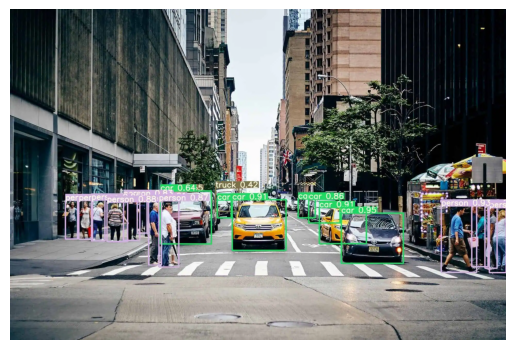

In [22]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()